# Telecom Customer Cancellation & Retention Analysis

This notebook performs exploratory data analysis on the Telecom Customer Churn dataset (Q2 2022) to evaluate key metrics, customer demographics, and main drivers of churn.

In [1]:
# Cell 2: Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Dataset
Locating and loading the telecom customer churn dataset from the `data/` folder[cite: 7].

In [10]:
# Cell 4: Load C1_Capstone dataset safely
import os
import pandas as pd

# Check relative paths dynamically
if os.path.exists('data/C1_Capstone_Customer_cancellation_analysis.xlsx'):
    file_path = 'data/C1_Capstone_Customer_cancellation_analysis.xlsx'
elif os.path.exists('../data/C1_Capstone_Customer_cancellation_analysis.xlsx'):
    file_path = '../data/C1_Capstone_Customer_cancellation_analysis.xlsx'
else:
    raise FileNotFoundError("Could not find C1_Capstone_Customer_cancellation_analysis.xlsx in data/ or ../data/")

# Load data sheet
df = pd.read_excel(file_path, sheet_name='Data')
print(f"Data loaded successfully from: {file_path}")
print(f"Total Customer Records: {len(df):,}")
display(df.head())

Data loaded successfully from: ../data/C1_Capstone_Customer_cancellation_analysis.xlsx
Total Customer Records: 7,043


,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churned,Stayed
0,0021-IKXGC,Female,72,No,0,San Marcos,0,1,Offer E,Yes,...,72.10,0.0,0,7.77,79.87,Joined,NaN,NaN,NaN,NaN
1,0023-HGHWL,Male,67,No,0,Morgan Hill,0,1,NaN,No,...,25.10,0.0,0,0.00,25.10,Churned,Competitor,Competitor made better offer,NaN,NaN
2,0032-PGELS,Female,37,Yes,1,Palomar Mountain,1,1,NaN,No,...,30.50,0.0,0,0.00,30.50,Churned,Attitude,Attitude of service provider,NaN,NaN
3,0082-LDZUE,Male,54,No,0,Calistoga,0,1,Offer E,Yes,...,44.30,0.0,0,42.95,87.25,Joined,NaN,NaN,NaN,NaN
4,0107-WESLM,Male,32,No,0,West Point,0,1,Offer E,Yes,...,19.85,0.0,0,31.77,51.62,Churned,Attitude,Attitude of support person,NaN,NaN


## 2. Key Metrics & Overall Churn Rate Analysis
Calculating overall churn rate, total churned customers, and contract distribution.

In [11]:
# Cell 6: Calculate churn KPIs
total_customers = len(df)

# Check if 'Customer Status' or 'Churn Value' column exists
if 'Customer Status' in df.columns:
    churned_df = df[df['Customer Status'] == 'Churned']
    churn_count = len(churned_df)
elif 'Churn Value' in df.columns:
    churned_df = df[df['Churn Value'] == 1]
    churn_count = len(churned_df)
else:
    # Default fallback check
    churn_count = (df['Customer Status'] == 'Churned').sum() if 'Customer Status' in df.columns else 0

churn_rate = (churn_count / total_customers) * 100

print(f"Total Customers: {total_customers:,}")
print(f"Total Churned Customers: {churn_count:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers: 7,043
Total Churned Customers: 1,869
Overall Churn Rate: 26.54%


## 3. Churn Analysis by Contract Duration
Evaluating customer drop-off based on contract types (Month-to-Month, One Year, Two Year).

In [12]:
# Cell 8: Group churn by Contract type
if 'Contract' in df.columns and 'Customer Status' in df.columns:
    contract_churn = df.groupby(['Contract', 'Customer Status']).size().unstack(fill_value=0)
    contract_churn['Churn Rate (%)'] = (contract_churn['Churned'] / (contract_churn['Churned'] + contract_churn['Joined'] + contract_churn['Stayed'])) * 100
    display(contract_churn)

Customer Status,Churned,Joined,Stayed,Churn Rate (%)
Contract,,,,
Month-to-Month,1655,408,1547,45.844875
One Year,166,24,1360,10.709677
Two Year,48,22,1813,2.549124


## 4. Visualizations & Visual Export
Generating key plots for contract churn, top churn reasons, and tenure distribution, then saving exports to the `visuals/` directory[cite: 10].

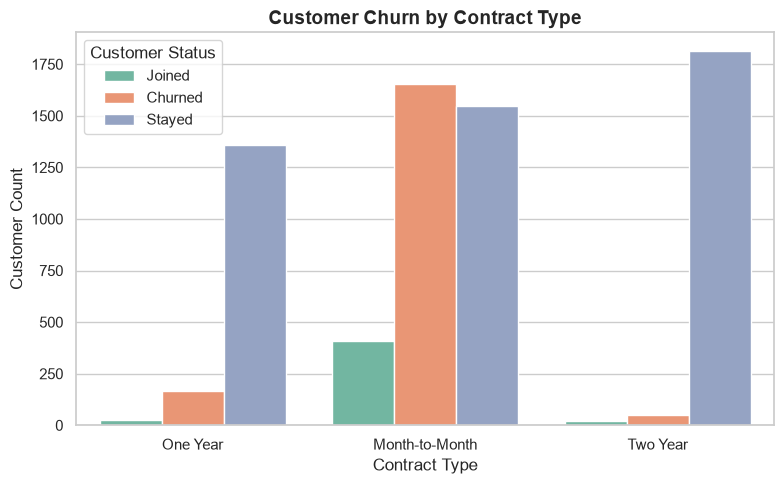

C:\Users\AVIRAJ\AppData\Local\Temp\ipykernel_9372\2029584576.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='viridis')


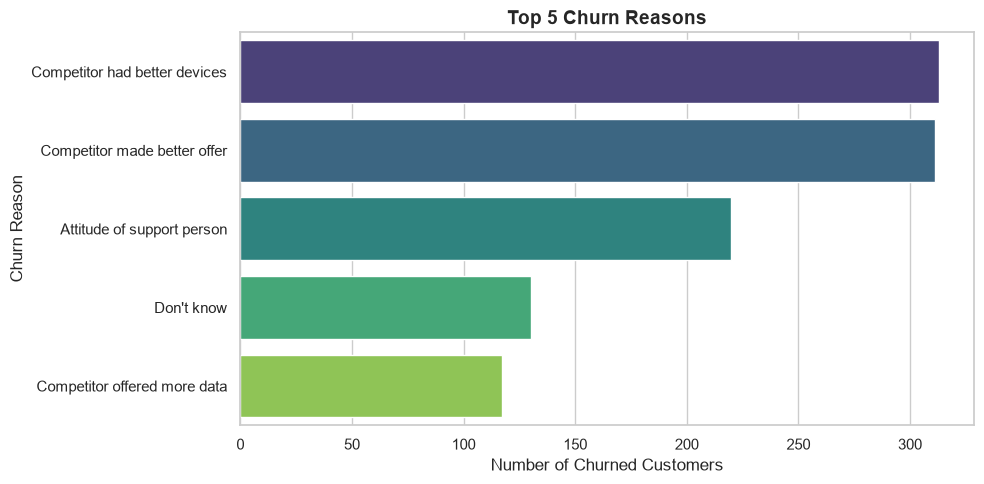

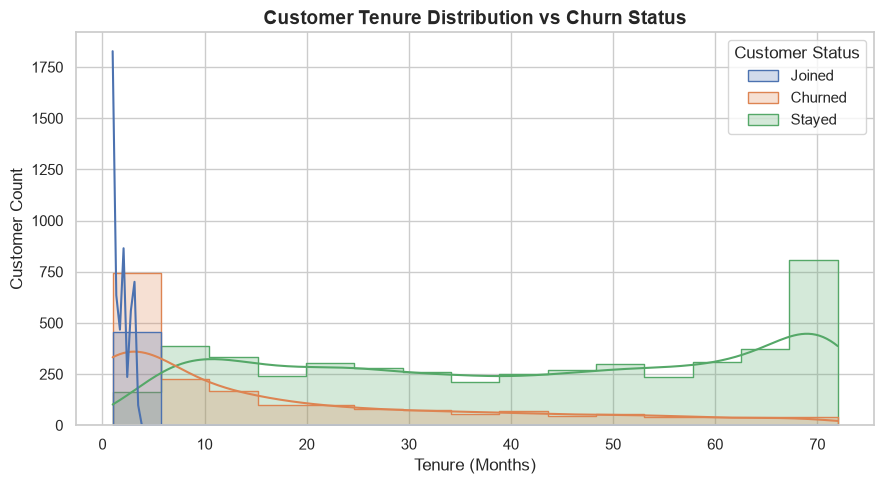

Visualizations saved successfully to c:\Users\AVIRAJ\OneDrive\Desktop\Pyhton Project\forest-fire-prevention\visuals/


In [13]:
# Cell 10: Generate visualizations and save exports to visuals/
output_dir = '../visuals' if os.path.exists('../visuals') else 'visuals'
os.makedirs(output_dir, exist_ok=True)

# Plot 1: Churn by Contract Type
plt.figure(figsize=(8, 5))
if 'Contract' in df.columns and 'Customer Status' in df.columns:
    sns.countplot(x='Contract', hue='Customer Status', data=df, palette='Set2')
    plt.title('Customer Churn by Contract Type', fontsize=14, fontweight='bold')
    plt.xlabel('Contract Type')
    plt.ylabel('Customer Count')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'churn_by_contract.png'), dpi=300)
    plt.show()

# Plot 2: Top Churn Reasons
plt.figure(figsize=(10, 5))
if 'Churn Reason' in df.columns:
    top_reasons = df['Churn Reason'].value_counts().head(5)
    sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='viridis')
    plt.title('Top 5 Churn Reasons', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Churned Customers')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'churn_reasons.png'), dpi=300)
    plt.show()

# Plot 3: Tenure in Months vs Churn Status
plt.figure(figsize=(9, 5))
if 'Tenure in Months' in df.columns and 'Customer Status' in df.columns:
    sns.histplot(data=df, x='Tenure in Months', hue='Customer Status', kde=True, element='step')
    plt.title('Customer Tenure Distribution vs Churn Status', fontsize=14, fontweight='bold')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Customer Count')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'tenure_vs_churn.png'), dpi=300)
    plt.show()

print(f"Visualizations saved successfully to {os.path.abspath(output_dir)}/")